In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [62]:
# %load 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
df=pd.read_csv('data/mobile.csv')

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [65]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [66]:
df.tail()

,Age,EstimatedSalary,Purchased
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0
399,49,36000,1


In [79]:
df['purchase_date'].dtype


KeyError: 'purchase_date'

In [78]:
df['purchase_date'] = pd.to_datetime(df['purchase_date'])


KeyError: 'purchase_date'

In [ ]:
df[purchase]

In [ ]:
df.isna().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [ ]:
purchase_data=df[["Age","EstimatedSalary","Purchased"]] 
purchase_data = df[["Age", "EstimatedSalary", "Purchased"]]

# Data where Purchased == 0
not_purchase_data = purchase_data[purchase_data["Purchased"] == 0]

# Data where Purchased == 1
purchase_data = purchase_data[purchase_data["Purchased"] == 1]


In [ ]:
purchase_data = df[["Age", "EstimatedSalary", "Purchased"]]

not_purchase_data = purchase_data[purchase_data["Purchased"] == 0]
purchase_data = purchase_data[purchase_data["Purchased"] == 1]



In [ ]:
import matplotlib.pyplot as plt

NameError: name 'purchase_data_yes' is not defined

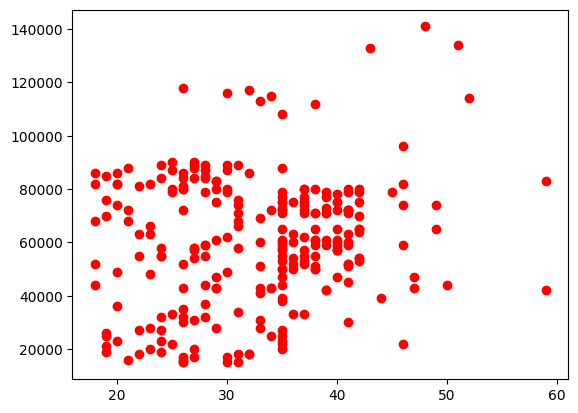

In [ ]:
plt.scatter(not_purchase_data["Age"], not_purchase_data["EstimatedSalary"],
            label="Not Purchased", marker='o', color='red')

plt.scatter(purchase_data_yes["Age"], purchase_data_yes["EstimatedSalary"],
            label="Purchased", marker='x', color='green')

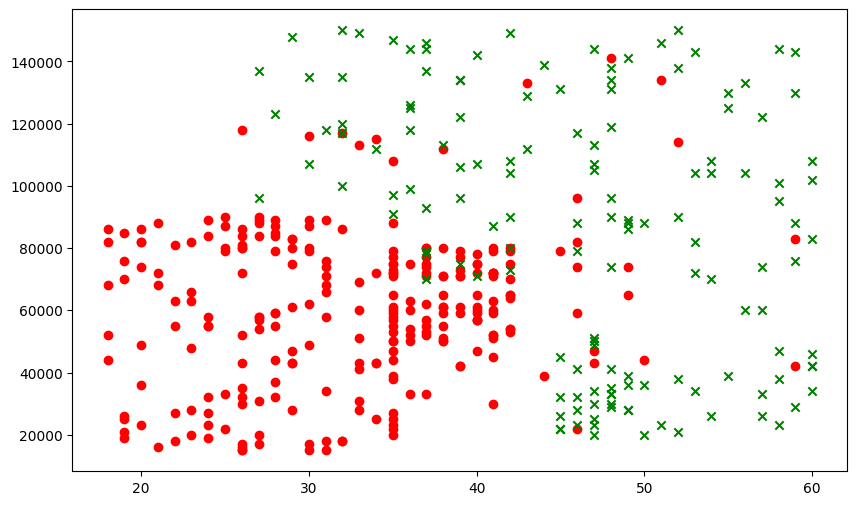

In [ ]:
# Filter data
purchase_data = df[["Age", "EstimatedSalary", "Purchased"]]
not_purchase_data = purchase_data[purchase_data["Purchased"] == 0]
purchase_data_yes = purchase_data[purchase_data["Purchased"] == 1]

# Plot
plt.figure(figsize=(10,6))

plt.scatter(not_purchase_data["Age"], not_purchase_data["EstimatedSalary"],
            label="Not Purchased", marker='o', color='red')

plt.scatter(purchase_data_yes["Age"], purchase_data_yes["EstimatedSalary"],
            label="Purchased", marker='x', color='green')

In [ ]:
not_purchase_data=[["age","EstimatedSalary"]]

Text(0.5, 1.0, 'Age vs Estimated Salary (Purchased vs Not Purchased)')

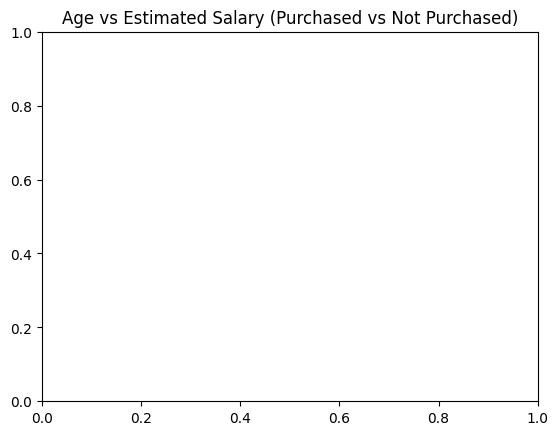

In [ ]:
plt.title("Age vs Estimated Salary (Purchased vs Not Purchased)")

In [ ]:
df['EstimatedSalary'].min

<bound method Series.min of 0      19000
1      20000
2      43000
3      57000
4      76000
       ...  
395    41000
396    23000
397    20000
398    33000
399    36000
Name: EstimatedSalary, Length: 400, dtype: int64>

In [ ]:
df['EstimatedSalary'].max()

np.int64(150000)

In [ ]:
df["Age"].min()

np.int64(18)

In [ ]:
df["Age"].max()

np.int64(60)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()                                                          

In [ ]:
features_to_scale = ["Age", "EstimatedSalary"]
scaled_values = scaler.fit_transform(df[features_to_scale])
df[features_to_scale] = scaled_values

In [ ]:
df["normalized_Age"] =scaled_values[:,0]
df["normalized_EstimatedSalary"] = scaled_values[:,1]

In [ ]:
df["normalized_Age"] = scaled_values[:,0]
df["norm_salary"] = scaled_values[:,1]

In [ ]:
df

,Age,EstimatedSalary,Purchased,normalized_Age,normalized_EstimatedSalary
0,0.023810,0.029630,0,0.023810,0.029630
1,0.404762,0.037037,0,0.404762,0.037037
2,0.190476,0.207407,0,0.190476,0.207407
3,0.214286,0.311111,0,0.214286,0.311111
4,0.023810,0.451852,0,0.023810,0.451852
...,...,...,...,...,...
395,0.666667,0.192593,1,0.666667,0.192593
396,0.785714,0.059259,1,0.785714,0.059259
397,0.761905,0.037037,1,0.761905,0.037037
398,0.428571,0.133333,0,0.428571,0.133333


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

features_to_scale = ["Age", "EstimatedSalary"]
scaled_values = scaler.fit_transform(df[features_to_scale])

df["normalized_Age"] = scaled_values[:,0]
df["norm_salary"] = scaled_values[:,1]

# X and y
X = df[["normalized_Age", "norm_salary"]]
y = df["Purchased"]


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [-4.17437535]
Coefficients: [[4.80288456 2.74975625]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5,metric='euclidean')
knn_model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()



In [ ]:
knn_model.score(X_test, y_test) * 100





NameError: name 'knn_model' is not defined

In [76]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=5,metric='euclidean')
knn_model.fit(X_train, y_train)

NameError: name 'X_train' is not defined